<a href="https://colab.research.google.com/github/Prachii26/DeepLearningCMPE258/blob/main/Deep_learning_training_design_space/Final_hyperparameter_tuning_tutorial(Prachi_Gupta).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hyperparameter Tuning for Deep Learning: From Zero to Hero

## A Comprehensive, Beginner-Friendly Guide

---

**Welcome!** This notebook will teach you how to find the best hyperparameters for your deep learning models - a crucial skill that separates good models from great ones.

### What You'll Learn

- What hyperparameters are and why they matter
- Manual tuning strategies and intuitions
- Automated search methods (Grid, Random, Bayesian)
- Modern tools (Optuna, Ray Tune)
- Best practices for efficient tuning

---

### Table of Contents

| Part | Topic | Key Concepts |
|------|-------|-------------|
| I | Introduction | Parameters vs Hyperparameters |
| II | Key Hyperparameters | Learning rate, batch size, architecture |
| III | Manual Tuning | Intuition and heuristics |
| IV | Grid Search | Exhaustive but expensive |
| V | Random Search | Often better than grid! |
| VI | Bayesian Optimization | Smart, adaptive search |
| VII | Optuna Tutorial | Modern hyperparameter optimization |
| VIII | Best Practices | Efficient tuning strategies |

In [1]:
# Install and import dependencies
!pip install -q numpy matplotlib torch scikit-learn optuna

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries loaded successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.2 MB/s eta 0:00:00
Libraries loaded successfully!


---

# Part I: Introduction to Hyperparameters

---

## 1.1 Parameters vs Hyperparameters

| Parameters | Hyperparameters |
|------------|----------------|
| **Learned** during training | **Set** before training |
| Weights, biases | Learning rate, batch size |
| Updated by optimizer | Chosen by you (or search) |
| Millions of them | Typically 10-50 |

### Why Hyperparameters Matter

The same architecture with different hyperparameters can give:
- **90% accuracy** with good hyperparameters
- **60% accuracy** with bad hyperparameters
- **Complete failure** with terrible hyperparameters

Hyperparameter tuning is often more important than architecture design!

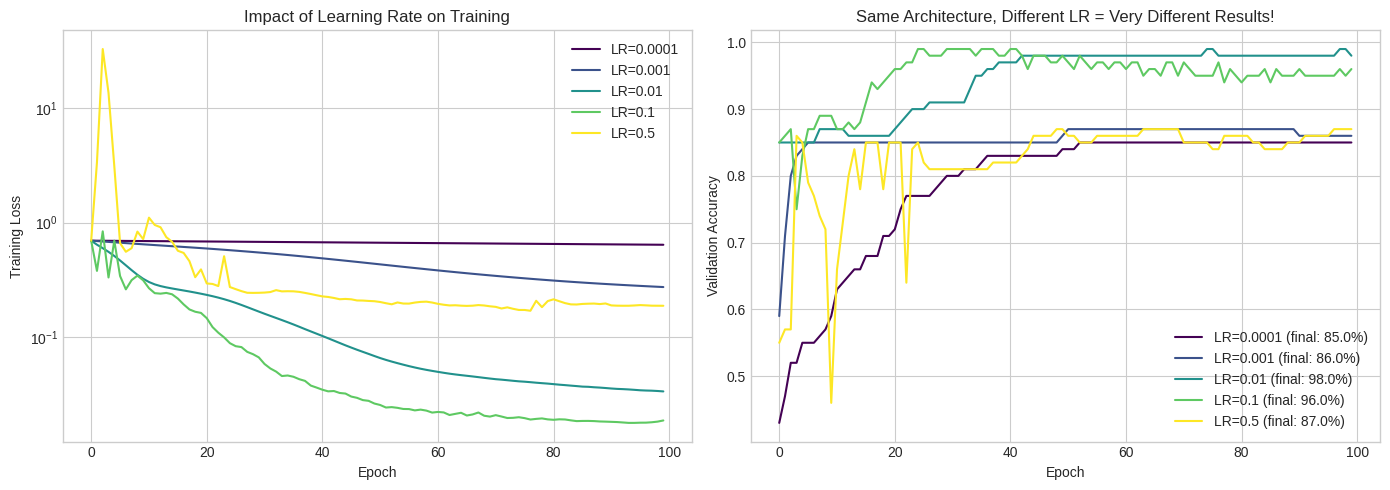


KEY INSIGHT: Learning rate alone can make or break training!
Finding good hyperparameters is crucial for success.


In [2]:
# Demonstrate impact of hyperparameters
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t = torch.FloatTensor(X_val)
y_val_t = torch.LongTensor(y_val)

class SimpleNet(nn.Module):
    def __init__(self, hidden_size=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 2)
        )

    def forward(self, x):
        return self.net(x)

def train_model(lr, hidden_size, epochs=100):
    torch.manual_seed(42)
    model = SimpleNet(hidden_size)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, val_accs = [], []
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            acc = (model(X_val_t).argmax(1) == y_val_t).float().mean().item()
            val_accs.append(acc)

    return train_losses, val_accs

# Test different learning rates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
colors = plt.cm.viridis(np.linspace(0, 1, len(learning_rates)))

for lr, color in zip(learning_rates, colors):
    losses, accs = train_model(lr, hidden_size=32)
    axes[0].plot(losses, color=color, label=f'LR={lr}')
    axes[1].plot(accs, color=color, label=f'LR={lr} (final: {accs[-1]:.1%})')

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Impact of Learning Rate on Training', fontsize=12)
axes[0].legend()
axes[0].set_yscale('log')

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Same Architecture, Different LR = Very Different Results!', fontsize=12)
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: Learning rate alone can make or break training!")
print("Finding good hyperparameters is crucial for success.")
print("="*60)

---

# Part II: Key Hyperparameters in Deep Learning

---

## 2.1 The Most Important Hyperparameters

| Category | Hyperparameter | Typical Range | Impact |
|----------|---------------|---------------|--------|
| **Optimization** | Learning rate | 1e-5 to 1e-1 | Very High |
| | Batch size | 16 to 512 | High |
| | Optimizer | Adam, SGD, AdamW | Medium |
| | Weight decay | 1e-5 to 1e-2 | Medium |
| **Architecture** | Hidden layers | 1 to 10+ | High |
| | Hidden units | 32 to 4096 | Medium |
| | Dropout rate | 0 to 0.5 | Medium |
| | Activation | ReLU, GELU | Low-Medium |
| **Training** | Epochs | 10 to 1000 | Medium |
| | LR schedule | Step, Cosine | Medium |

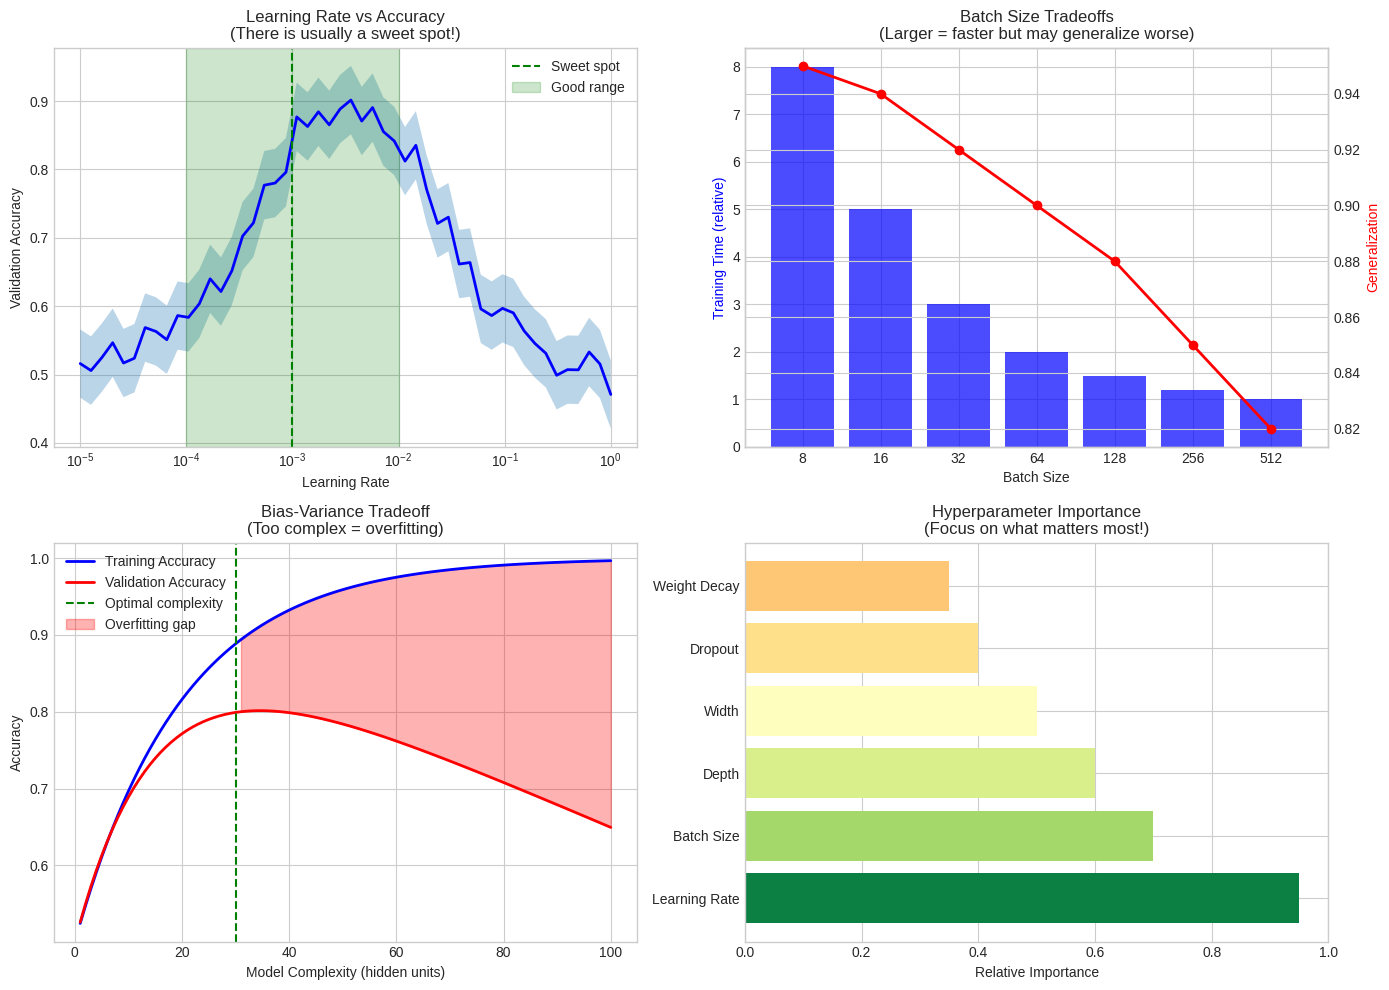

In [3]:
# Visualize hyperparameter search space
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Learning rate landscape
ax = axes[0, 0]
lrs = np.logspace(-5, 0, 50)
# Simulate typical accuracy vs LR curve
acc_curve = 0.5 + 0.4 * np.exp(-((np.log10(lrs) + 2.5)**2) / 1.5)
acc_curve += np.random.randn(50) * 0.02
ax.semilogx(lrs, acc_curve, 'b-', linewidth=2)
ax.fill_between(lrs, acc_curve - 0.05, acc_curve + 0.05, alpha=0.3)
ax.axvline(x=0.001, color='green', linestyle='--', label='Sweet spot')
ax.axvspan(0.0001, 0.01, alpha=0.2, color='green', label='Good range')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Learning Rate vs Accuracy\n(There is usually a sweet spot!)', fontsize=12)
ax.legend()

# Batch size tradeoffs
ax = axes[0, 1]
batch_sizes = [8, 16, 32, 64, 128, 256, 512]
train_time = [8, 5, 3, 2, 1.5, 1.2, 1]  # Relative
generalization = [0.95, 0.94, 0.92, 0.90, 0.88, 0.85, 0.82]  # Hypothetical

ax2 = ax.twinx()
ax.bar([str(b) for b in batch_sizes], train_time, alpha=0.7, color='blue', label='Training Time')
ax2.plot([str(b) for b in batch_sizes], generalization, 'ro-', linewidth=2, label='Generalization')
ax.set_xlabel('Batch Size')
ax.set_ylabel('Training Time (relative)', color='blue')
ax2.set_ylabel('Generalization', color='red')
ax.set_title('Batch Size Tradeoffs\n(Larger = faster but may generalize worse)', fontsize=12)

# Model complexity vs performance
ax = axes[1, 0]
complexity = np.linspace(1, 100, 100)
train_acc = 0.5 + 0.5 * (1 - np.exp(-complexity/20))
val_acc = 0.5 + 0.45 * (1 - np.exp(-complexity/15)) - 0.003 * complexity
val_acc = np.maximum(val_acc, 0.3)

ax.plot(complexity, train_acc, 'b-', linewidth=2, label='Training Accuracy')
ax.plot(complexity, val_acc, 'r-', linewidth=2, label='Validation Accuracy')
ax.axvline(x=30, color='green', linestyle='--', label='Optimal complexity')
ax.fill_between(complexity[30:], train_acc[30:], val_acc[30:], alpha=0.3, color='red', label='Overfitting gap')
ax.set_xlabel('Model Complexity (hidden units)')
ax.set_ylabel('Accuracy')
ax.set_title('Bias-Variance Tradeoff\n(Too complex = overfitting)', fontsize=12)
ax.legend()

# Hyperparameter importance
ax = axes[1, 1]
params = ['Learning Rate', 'Batch Size', 'Depth', 'Width', 'Dropout', 'Weight Decay']
importance = [0.95, 0.7, 0.6, 0.5, 0.4, 0.35]
colors = plt.cm.RdYlGn(np.array(importance))
ax.barh(params, importance, color=colors)
ax.set_xlabel('Relative Importance')
ax.set_title('Hyperparameter Importance\n(Focus on what matters most!)', fontsize=12)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

---

# Part III: Manual Tuning Strategies

---

## 3.1 The Learning Rate Finder

Start with learning rate - it's the most important!

**Strategy**: Gradually increase LR and watch the loss
- If loss **decreases** → LR is in good range
- If loss **explodes** → LR is too high
- If loss **barely moves** → LR is too low

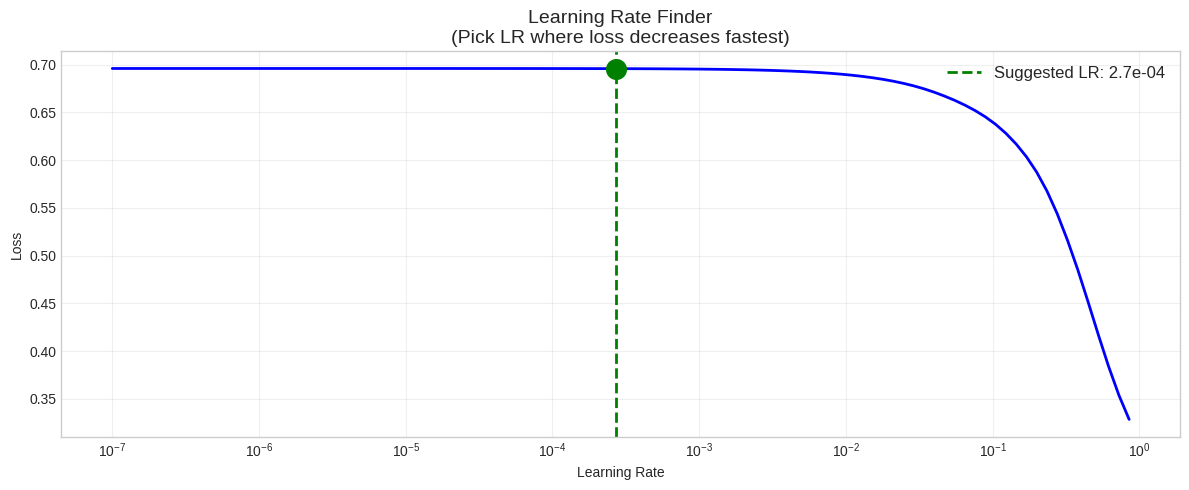


Suggested learning rate: 2.7e-04
(Use a value slightly lower for stable training)


In [4]:
# Learning Rate Finder implementation
def lr_finder(model_class, train_data, start_lr=1e-7, end_lr=1, num_steps=100):
    """Find optimal learning rate by gradually increasing it."""
    X_t, y_t = train_data
    torch.manual_seed(42)
    model = model_class()
    optimizer = optim.SGD(model.parameters(), lr=start_lr)
    criterion = nn.CrossEntropyLoss()

    # Exponential LR increase
    lr_mult = (end_lr / start_lr) ** (1 / num_steps)

    lrs, losses = [], []
    lr = start_lr
    best_loss = float('inf')

    for _ in range(num_steps):
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)

        # Stop if loss explodes
        if loss.item() > 4 * best_loss or np.isnan(loss.item()):
            break

        best_loss = min(best_loss, loss.item())
        lrs.append(lr)
        losses.append(loss.item())

        loss.backward()
        optimizer.step()

        # Increase learning rate
        lr *= lr_mult
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

    return lrs, losses

# Run LR finder
lrs, losses = lr_finder(SimpleNet, (X_train_t, y_train_t))

fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogx(lrs, losses, 'b-', linewidth=2)

# Find suggested LR (steepest descent point)
gradients = np.gradient(losses)
min_grad_idx = np.argmin(gradients[:len(gradients)//2])  # First half only
suggested_lr = lrs[min_grad_idx]

ax.axvline(x=suggested_lr, color='green', linestyle='--', linewidth=2,
           label=f'Suggested LR: {suggested_lr:.1e}')
ax.scatter([suggested_lr], [losses[min_grad_idx]], color='green', s=200, zorder=5)

ax.set_xlabel('Learning Rate')
ax.set_ylabel('Loss')
ax.set_title('Learning Rate Finder\n(Pick LR where loss decreases fastest)', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSuggested learning rate: {suggested_lr:.1e}")
print("(Use a value slightly lower for stable training)")

---

# Part IV: Grid Search

---

## 4.1 What is Grid Search?

Try **every combination** of hyperparameter values:

```
LR:     [0.001, 0.01, 0.1]
Hidden: [32, 64, 128]

Grid:
(0.001, 32), (0.001, 64), (0.001, 128),
(0.01, 32),  (0.01, 64),  (0.01, 128),
(0.1, 32),   (0.1, 64),   (0.1, 128)

Total: 3 × 3 = 9 combinations
```

### Pros and Cons

| Pros | Cons |
|------|------|
| Complete coverage | Exponential growth |
| Reproducible | Wastes time on bad regions |
| Easy to parallelize | Requires good grid design |

In [5]:
# Grid Search implementation
from itertools import product

def evaluate_hyperparams(lr, hidden_size, dropout=0.0, epochs=50):
    """Train and evaluate with given hyperparameters."""
    torch.manual_seed(42)

    model = nn.Sequential(
        nn.Linear(2, hidden_size),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_size, hidden_size),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(hidden_size, 2)
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_acc = (model(X_val_t).argmax(1) == y_val_t).float().mean().item()

    return val_acc

# Define grid
lr_grid = [0.001, 0.01, 0.1]
hidden_grid = [16, 32, 64, 128]

# Run grid search
results = {}
print("Running Grid Search...")
for lr, hidden in product(lr_grid, hidden_grid):
    acc = evaluate_hyperparams(lr, hidden)
    results[(lr, hidden)] = acc
    print(f"  LR={lr}, Hidden={hidden}: Accuracy={acc:.2%}")

# Find best
best_params = max(results, key=results.get)
print(f"\nBest: LR={best_params[0]}, Hidden={best_params[1]} → {results[best_params]:.2%}")

Running Grid Search...
  LR=0.001, Hidden=16: Accuracy=85.00%
  LR=0.001, Hidden=32: Accuracy=86.00%
  LR=0.001, Hidden=64: Accuracy=86.00%
  LR=0.001, Hidden=128: Accuracy=90.00%
  LR=0.01, Hidden=16: Accuracy=88.00%
  LR=0.01, Hidden=32: Accuracy=98.00%
  LR=0.01, Hidden=64: Accuracy=99.00%
  LR=0.01, Hidden=128: Accuracy=97.00%
  LR=0.1, Hidden=16: Accuracy=96.00%
  LR=0.1, Hidden=32: Accuracy=98.00%
  LR=0.1, Hidden=64: Accuracy=99.00%
  LR=0.1, Hidden=128: Accuracy=98.00%

Best: LR=0.01, Hidden=64 → 99.00%


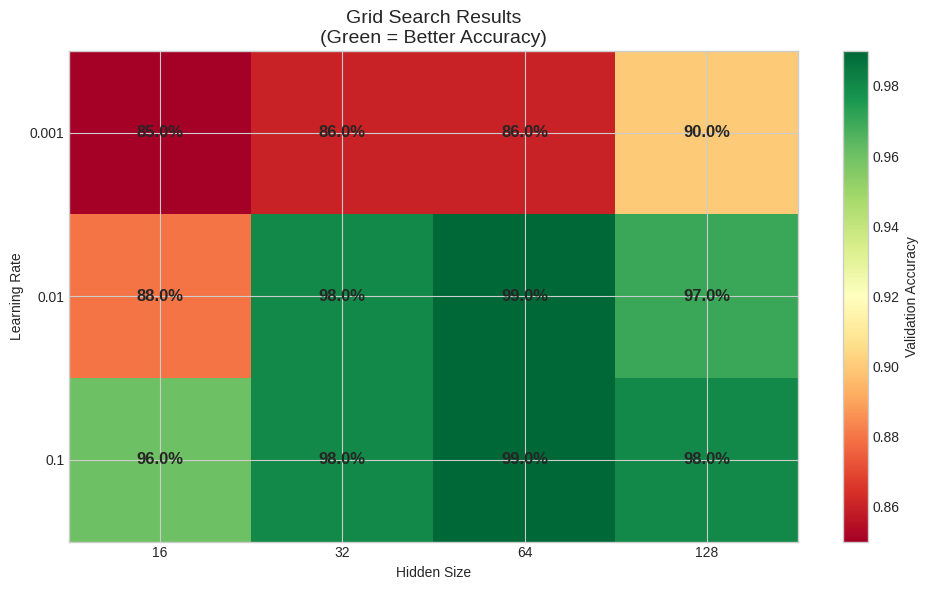

In [6]:
# Visualize grid search results
fig, ax = plt.subplots(figsize=(10, 6))

# Create heatmap
acc_matrix = np.zeros((len(lr_grid), len(hidden_grid)))
for i, lr in enumerate(lr_grid):
    for j, hidden in enumerate(hidden_grid):
        acc_matrix[i, j] = results[(lr, hidden)]

im = ax.imshow(acc_matrix, cmap='RdYlGn', aspect='auto')
ax.set_xticks(range(len(hidden_grid)))
ax.set_yticks(range(len(lr_grid)))
ax.set_xticklabels(hidden_grid)
ax.set_yticklabels(lr_grid)
ax.set_xlabel('Hidden Size')
ax.set_ylabel('Learning Rate')
ax.set_title('Grid Search Results\n(Green = Better Accuracy)', fontsize=14)

# Add text annotations
for i in range(len(lr_grid)):
    for j in range(len(hidden_grid)):
        text = ax.text(j, i, f'{acc_matrix[i, j]:.1%}',
                       ha='center', va='center', fontsize=12, fontweight='bold')

plt.colorbar(im, label='Validation Accuracy')
plt.tight_layout()
plt.show()

---

# Part V: Random Search

---

## 5.1 Why Random Search?

**Key Insight**: For most problems, only a few hyperparameters really matter!

Random search explores more values of important hyperparameters by chance.

### Research Finding (Bergstra & Bengio, 2012)

> "Random search is more efficient than grid search in high-dimensional spaces"

With the same budget:
- Grid search: 9 points in a 3×3 grid
- Random search: 9 different values of each parameter!

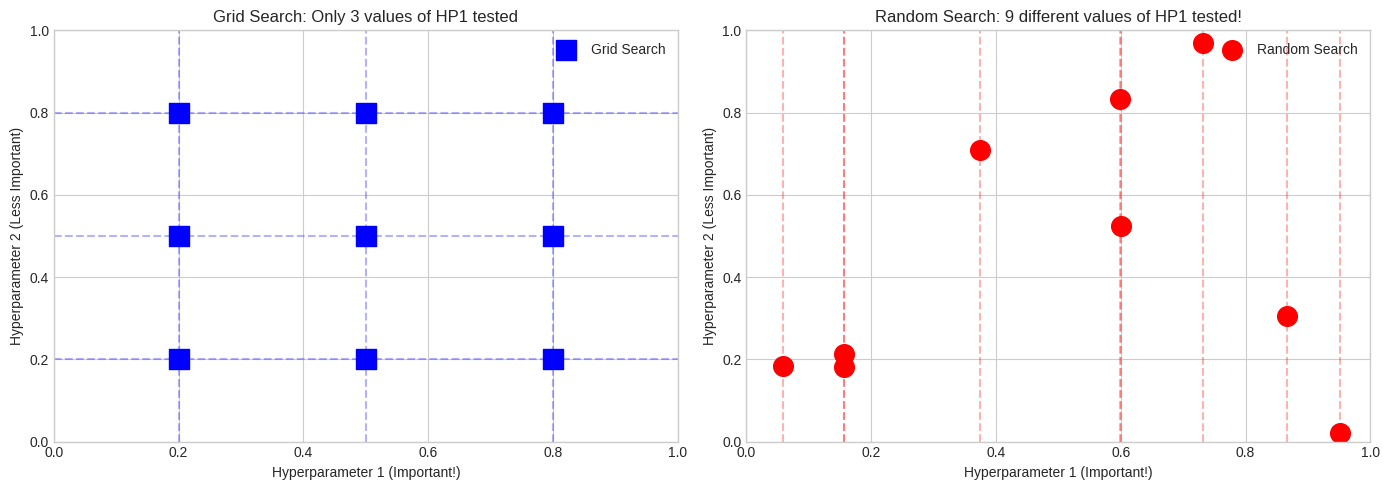


KEY INSIGHT: Random search covers more unique values!
If only HP1 matters, random search tests 9 values vs 3.


In [7]:
# Visualize Grid vs Random search
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

np.random.seed(42)

# Grid search points
ax = axes[0]
grid_x = np.array([0.2, 0.5, 0.8])
grid_y = np.array([0.2, 0.5, 0.8])
grid_xx, grid_yy = np.meshgrid(grid_x, grid_y)
ax.scatter(grid_xx, grid_yy, s=200, c='blue', marker='s', label='Grid Search')

# Show projections
for x in grid_x:
    ax.axvline(x=x, color='blue', alpha=0.3, linestyle='--')
for y in grid_y:
    ax.axhline(y=y, color='blue', alpha=0.3, linestyle='--')

ax.set_xlabel('Hyperparameter 1 (Important!)')
ax.set_ylabel('Hyperparameter 2 (Less Important)')
ax.set_title('Grid Search: Only 3 values of HP1 tested', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

# Random search points
ax = axes[1]
rand_x = np.random.rand(9)
rand_y = np.random.rand(9)
ax.scatter(rand_x, rand_y, s=200, c='red', marker='o', label='Random Search')

# Show projections on x-axis (important parameter)
for x in rand_x:
    ax.axvline(x=x, color='red', alpha=0.3, linestyle='--')

ax.set_xlabel('Hyperparameter 1 (Important!)')
ax.set_ylabel('Hyperparameter 2 (Less Important)')
ax.set_title('Random Search: 9 different values of HP1 tested!', fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("KEY INSIGHT: Random search covers more unique values!")
print("If only HP1 matters, random search tests 9 values vs 3.")
print("="*60)

In [8]:
# Random Search implementation
def random_search(n_trials=20):
    """Perform random search over hyperparameter space."""
    results = []

    for trial in range(n_trials):
        # Sample hyperparameters randomly
        lr = 10 ** np.random.uniform(-4, -1)  # Log-uniform: 0.0001 to 0.1
        hidden = int(2 ** np.random.uniform(4, 8))  # 16 to 256
        dropout = np.random.uniform(0, 0.5)

        acc = evaluate_hyperparams(lr, hidden, dropout)
        results.append({'lr': lr, 'hidden': hidden, 'dropout': dropout, 'accuracy': acc})

        if (trial + 1) % 5 == 0:
            print(f"Trial {trial+1}/{n_trials}: Best so far = {max(r['accuracy'] for r in results):.2%}")

    return results

# Run random search
print("Running Random Search...")
random_results = random_search(n_trials=20)

# Find best
best = max(random_results, key=lambda x: x['accuracy'])
print(f"\nBest found:")
print(f"  LR: {best['lr']:.4f}")
print(f"  Hidden: {best['hidden']}")
print(f"  Dropout: {best['dropout']:.2f}")
print(f"  Accuracy: {best['accuracy']:.2%}")

Running Random Search...
Trial 5/20: Best so far = 98.00%
Trial 10/20: Best so far = 99.00%
Trial 15/20: Best so far = 99.00%
Trial 20/20: Best so far = 99.00%

Best found:
  LR: 0.0703
  Hidden: 232
  Dropout: 0.40
  Accuracy: 99.00%


---

# Part VI: Bayesian Optimization

---

## 6.1 The Smart Search

Bayesian optimization **learns from previous trials** to suggest better points!

### How It Works

1. **Build a model** of the objective function (surrogate model)
2. **Use it to predict** promising regions
3. **Balance exploration vs exploitation**
4. **Update the model** after each trial

### Key Concepts

- **Surrogate Model**: Gaussian Process or Tree Parzen Estimator
- **Acquisition Function**: Decides where to sample next
- **Expected Improvement**: Common acquisition function

---

# Part VII: Optuna Tutorial

---

## 7.1 Modern Hyperparameter Optimization

**Optuna** is a state-of-the-art hyperparameter optimization framework:
- Automatic pruning of bad trials
- Efficient sampling algorithms
- Easy to use API
- Great visualizations

In [9]:
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances

def objective(trial):
    """Optuna objective function."""
    # Suggest hyperparameters
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    hidden_size = trial.suggest_int('hidden_size', 16, 256)
    dropout = trial.suggest_float('dropout', 0.0, 0.5)
    n_layers = trial.suggest_int('n_layers', 1, 4)

    # Build model
    torch.manual_seed(42)
    layers = []
    in_size = 2
    for _ in range(n_layers):
        layers.extend([
            nn.Linear(in_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout)
        ])
        in_size = hidden_size
    layers.append(nn.Linear(hidden_size, 2))
    model = nn.Sequential(*layers)

    # Train
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(50):
        optimizer.zero_grad()
        loss = criterion(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

        # Pruning: Stop bad trials early
        model.eval()
        with torch.no_grad():
            val_acc = (model(X_val_t).argmax(1) == y_val_t).float().mean().item()
        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
        model.train()

    return val_acc

# Run Optuna optimization
study = optuna.create_study(direction='maximize',
                           pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n" + "="*60)
print("OPTUNA RESULTS")
print("="*60)
print(f"Best accuracy: {study.best_value:.2%}")
print(f"Best hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-04-10 18:09:44,351] A new study created in memory with name: no-name-a0986208-4fd7-4f6c-a44b-cfcd4c406645


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-10 18:09:44,596] Trial 0 finished with value: 0.8600000143051147 and parameters: {'lr': 0.00038369039578231416, 'hidden_size': 151, 'dropout': 0.08595487994843348, 'n_layers': 2}. Best is trial 0 with value: 0.8600000143051147.
[I 2026-04-10 18:09:44,725] Trial 1 finished with value: 0.8999999761581421 and parameters: {'lr': 0.006758758478256605, 'hidden_size': 98, 'dropout': 0.4181480816473925, 'n_layers': 1}. Best is trial 1 with value: 0.8999999761581421.
[I 2026-04-10 18:09:44,870] Trial 2 finished with value: 0.9800000190734863 and parameters: {'lr': 0.0122886665569153, 'hidden_size': 173, 'dropout': 0.11498401369659983, 'n_layers': 1}. Best is trial 2 with value: 0.9800000190734863.
[I 2026-04-10 18:09:45,047] Trial 3 finished with value: 0.8700000047683716 and parameters: {'lr': 0.00011314018833392942, 'hidden_size': 254, 'dropout': 0.34939437568542336, 'n_layers': 1}. Best is trial 2 with value: 0.9800000190734863.
[I 2026-04-10 18:09:45,177] Trial 4 finished with va

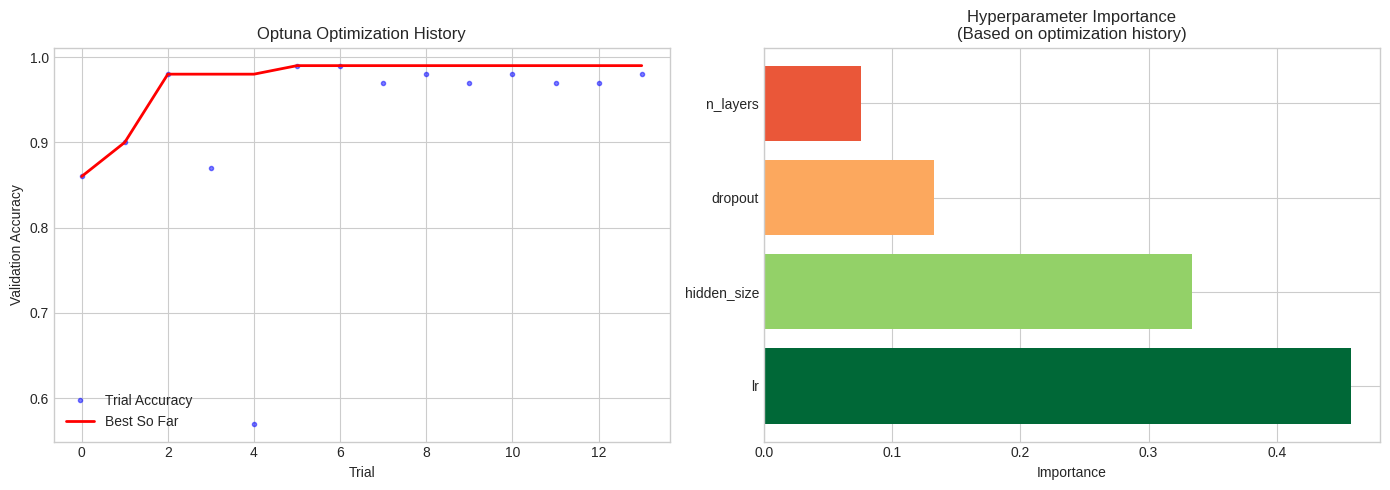

In [10]:
# Visualize Optuna results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
ax = axes[0]
trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
values = [t.value for t in trials]
best_values = np.maximum.accumulate(values)
ax.plot(values, 'b.', alpha=0.5, label='Trial Accuracy')
ax.plot(best_values, 'r-', linewidth=2, label='Best So Far')
ax.set_xlabel('Trial')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Optuna Optimization History', fontsize=12)
ax.legend()

# Parameter importance
ax = axes[1]
importances = optuna.importance.get_param_importances(study)
params = list(importances.keys())
values = list(importances.values())
colors = plt.cm.RdYlGn(np.array(values) / max(values))
ax.barh(params, values, color=colors)
ax.set_xlabel('Importance')
ax.set_title('Hyperparameter Importance\n(Based on optimization history)', fontsize=12)

plt.tight_layout()
plt.show()

---

# Part VIII: Best Practices

---

## 8.1 Efficient Tuning Strategy

```
1. START SIMPLE
   └── Use defaults, ensure code works
   
2. FIND LEARNING RATE
   └── Use LR finder or coarse search
   
3. TUNE IMPORTANT PARAMS FIRST
   └── LR, batch size, then architecture
   
4. USE RANDOM/BAYESIAN SEARCH
   └── More efficient than grid search
   
5. USE EARLY STOPPING
   └── Don't waste time on bad configs
   
6. SCALE UP GRADUALLY
   └── Start small, increase budget for promising regions
```

## 8.2 Common Mistakes to Avoid

| Mistake | Why It's Bad | Solution |
|---------|--------------|----------|
| Tuning on test set | Data leakage! | Use validation set |
| Too wide ranges | Wastes trials | Start narrow, expand |
| Ignoring interactions | Missing good combos | Use Bayesian optimization |
| Linear search for LR | Wrong scale | Use log scale |
| No reproducibility | Can't repeat results | Set random seeds |

## 8.3 Summary Cheat Sheet

```
┌─────────────────────────────────────────────────────────┐
│           HYPERPARAMETER TUNING CHEAT SHEET            │
├─────────────────────────────────────────────────────────┤
│ Learning Rate:                                         │
│   • Start: 1e-3 (Adam), 0.1 (SGD)                     │
│   • Search: Log scale [1e-5, 1e-1]                    │
│   • Use LR finder or warmup                           │
├─────────────────────────────────────────────────────────┤
│ Batch Size:                                            │
│   • Start: 32 or 64                                   │
│   • Larger = faster but may need LR adjustment        │
│   • Powers of 2 for GPU efficiency                    │
├─────────────────────────────────────────────────────────┤
│ Architecture:                                          │
│   • Start small, increase if underfitting             │
│   • Use dropout (0.1-0.5) for regularization          │
│   • Modern activations: ReLU, GELU                    │
├─────────────────────────────────────────────────────────┤
│ Search Strategy:                                       │
│   • Few params: Grid search                           │
│   • Many params: Random or Bayesian                   │
│   • Production: Optuna, Ray Tune                      │
└─────────────────────────────────────────────────────────┘
```

**Congratulations!** You now know how to tune hyperparameters like a pro!